# 02 — Clasificación y análisis con LLM — Black Basta

Clasifica una muestra estratificada de mensajes con `qwen2.5:14b` y perfila los 49 actores.  
Con solo 49 actores (vs 485 en Conti) podemos ser más exhaustivos: 80 msgs/actor.

Produce:
- `data/processed/bb_sample_classified.parquet`
- `data/processed/bb_actor_profiles.json`


## 0. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../src').resolve()))

import json
import time
import pandas as pd
import ollama
from tqdm.auto import tqdm

PROCESSED_DIR   = Path('../data/processed')
PARQUET_IN      = PROCESSED_DIR / 'blackbasta_unified.parquet'
PARQUET_OUT     = PROCESSED_DIR / 'bb_sample_classified.parquet'
PROFILES_OUT    = PROCESSED_DIR / 'bb_actor_profiles.json'
CHECKPOINT_PATH = PROCESSED_DIR / 'bb_checkpoint_classified.parquet'

MODEL = 'qwen2.5:14b'

assert PARQUET_IN.exists(), f'No se encuentra {PARQUET_IN} — ejecuta primero el notebook 01'
print('Setup OK')

Setup OK


/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cargar dataset

In [2]:
df = pd.read_parquet(PARQUET_IN)

print(f'Mensajes : {len(df):,}')
print(f'Actores  : {df.username.nunique()}')
print(f'Canales  : {df.channel.nunique()}')
print(f'Rango    : {df.timestamp.min().date()} → {df.timestamp.max().date()}')

Mensajes : 195,397
Actores  : 49
Canales  : 79
Rango    : 2023-09-18 → 2024-09-28


## 2. Muestreo — todos los actores, 80 msgs cada uno

Con 49 actores × 80 mensajes = ~3 900 mensajes.  
Muestra distribuida uniformemente en el tiempo por actor.

In [3]:
MSGS_PER_ACTOR = 80

# Filtrar actores con suficientes mensajes
MIN_MSGS = 10
actor_counts = df.groupby('username').size()
valid_actors = actor_counts[actor_counts >= MIN_MSGS].index.tolist()
print(f'Actores con ≥{MIN_MSGS} mensajes: {len(valid_actors)} de {df.username.nunique()}')

def sample_actor(actor_df: pd.DataFrame, n: int) -> pd.DataFrame:
    actor_df = actor_df.sort_values('timestamp').reset_index(drop=True)
    if len(actor_df) <= n:
        return actor_df
    indices = [int(i * len(actor_df) / n) for i in range(n)]
    return actor_df.iloc[indices]

frames = [sample_actor(df[df['username'] == a], MSGS_PER_ACTOR) for a in valid_actors]
sample = pd.concat(frames, ignore_index=True).sort_values('timestamp').reset_index(drop=True)

print(f'Muestra total: {len(sample):,} mensajes de {sample.username.nunique()} actores')

Actores con ≥10 mensajes: 47 de 49
Muestra total: 3,598 mensajes de 47 actores


## 3. Clasificación de mensajes

Mismas categorías que Conti para poder comparar entre grupos.

In [4]:
CATEGORIES = {'technical', 'operational', 'financial', 'organizational', 'comms', 'unknown'}

SYSTEM_PROMPT = """You are a threat intelligence analyst classifying messages from the leaked Black Basta ransomware group chats.
Messages are mostly in Russian. Classify each message into exactly one category:
- technical: malware development, builds, code, infrastructure, bugs, tools
- operational: attacks, targets, victims, accesses, deployment, reconnaissance
- financial: payments, bitcoin, ransom negotiations, money, commissions
- organizational: management, task assignments, team structure, HR, recruitment
- comms: general conversation, greetings, scheduling, off-topic
- unknown: too short or ambiguous to classify

Reply with ONLY the category name, nothing else."""

def classify_message(text: str) -> str:
    if len(text.strip()) < 5:
        return 'unknown'
    try:
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user',   'content': f'Message: {text[:400]}'}
            ],
            options={'temperature': 0, 'num_predict': 10}
        )
        raw = resp.message.content.strip().lower().split()[0].rstrip('.,:')
        return raw if raw in CATEGORIES else 'unknown'
    except Exception:
        return 'unknown'

print('Test clasificación:')
print(f'  técnico     → {classify_message("Нужно собрать новый билд для x64")}')
print(f'  financiero  → {classify_message("переведи биткоины на кошелек")}')

Test clasificación:
  técnico     → technical
  financiero  → financial


In [5]:
if CHECKPOINT_PATH.exists():
    done = pd.read_parquet(CHECKPOINT_PATH)
    done_ids = set(done.index)
    print(f'Checkpoint: {len(done):,} mensajes ya clasificados')
else:
    done = pd.DataFrame()
    done_ids = set()
    print('Comenzando desde cero')

todo = sample[~sample.index.isin(done_ids)].copy()
print(f'Pendientes: {len(todo):,}')

Comenzando desde cero
Pendientes: 3,598


In [6]:
CHECKPOINT_EVERY = 50

results = []
t0 = time.time()

for i, (idx, row) in enumerate(tqdm(todo.iterrows(), total=len(todo), desc='Clasificando')):
    cat = classify_message(row['message'])
    results.append({'idx': idx, 'category': cat})

    if (i + 1) % CHECKPOINT_EVERY == 0:
        chunk = pd.DataFrame(results).set_index('idx')
        partial = pd.concat([done, sample.loc[chunk.index].assign(category=chunk['category'])])
        partial.to_parquet(CHECKPOINT_PATH)

elapsed = time.time() - t0
print(f'\nCompletado en {elapsed/60:.1f} min ({elapsed/max(len(todo),1):.1f} s/msg)')

new_df = pd.DataFrame(results).set_index('idx')
sample_new = sample.loc[new_df.index].copy()
sample_new['category'] = new_df['category'].values
classified = pd.concat([done, sample_new]).sort_values('timestamp').reset_index(drop=True)
print(f'Total clasificados: {len(classified):,}')

Clasificando: 100%|██████████████████████████████████████████████████████████████████████| 3598/3598 [07:06<00:00,  8.44it/s]


Completado en 7.1 min (0.1 s/msg)
Total clasificados: 3,598


## 4. Análisis de resultados

In [7]:
import matplotlib.pyplot as plt
import numpy as np

cat_order = ['technical', 'operational', 'financial', 'organizational', 'comms', 'unknown']
cat_order = [c for c in cat_order if c in classified['category'].unique()]

print('=== Distribución global de categorías ===')
cat_counts = classified['category'].value_counts()
print(cat_counts.to_string())

=== Distribución global de categorías ===
category
technical         1054
comms             1051
unknown            777
operational        543
financial          122
organizational      51


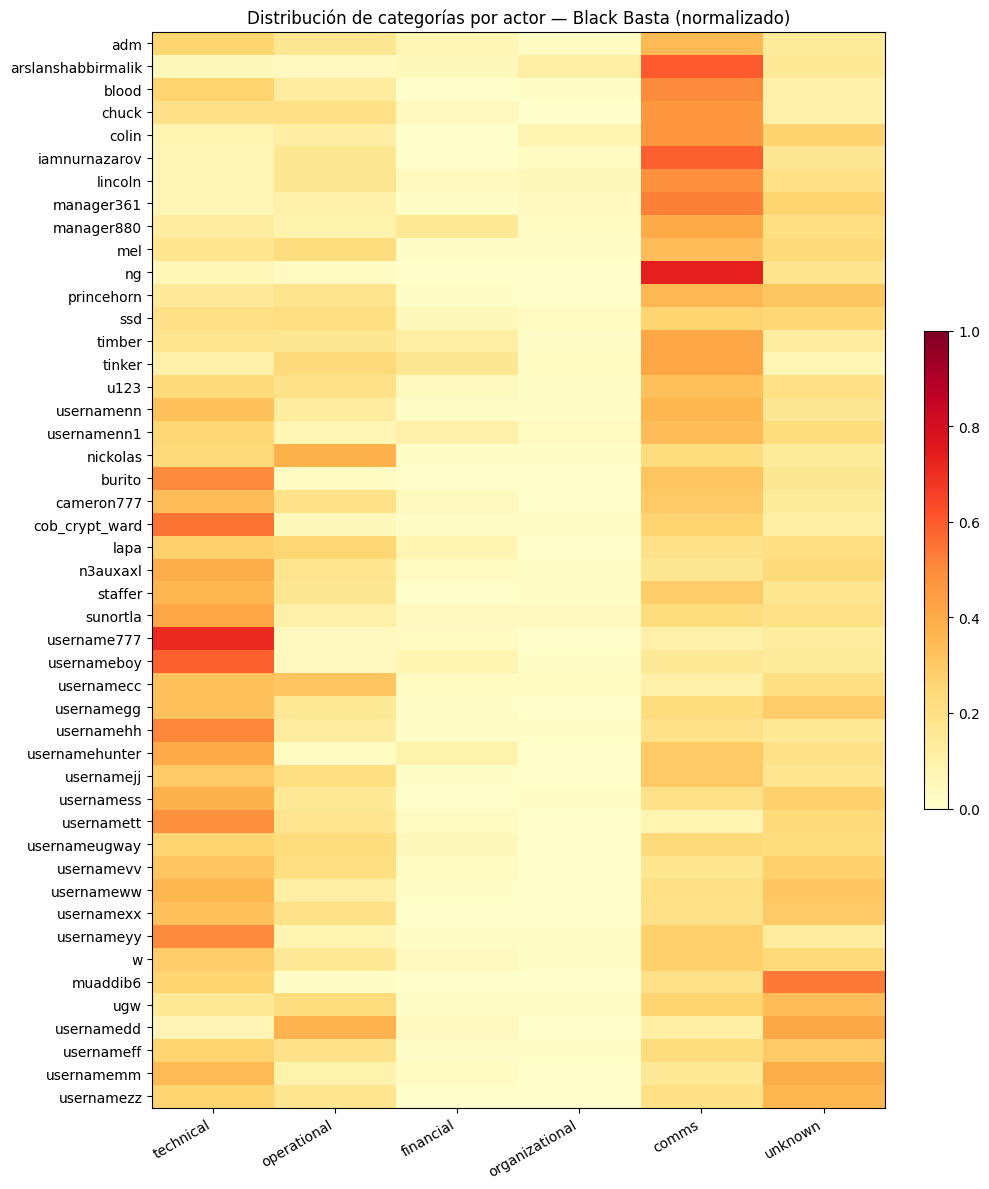

In [8]:
pivot = classified.groupby(['username', 'category']).size().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
pivot_norm = pivot_norm[[c for c in cat_order if c in pivot_norm.columns]]
pivot_norm = pivot_norm.loc[pivot_norm.idxmax(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, 12))
im = ax.imshow(pivot_norm.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot_norm.columns)))
ax.set_xticklabels(pivot_norm.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot_norm)))
ax.set_yticklabels(pivot_norm.index)
ax.set_title('Distribución de categorías por actor — Black Basta (normalizado)')
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

## 5. Perfilado de actores

In [9]:
PROFILE_SYSTEM = """You are a threat intelligence analyst studying the Black Basta ransomware group.
Given a sample of messages from one member, infer their role in the organization.

Reply in JSON with these fields:
{
  "role": "<one of: leader, developer, operator, negotiator, affiliate, support, unknown>",
  "confidence": "<high|medium|low>",
  "summary": "<2-3 sentences in English describing their responsibilities>",
  "evidence": ["<quote or paraphrase from messages, max 3>"]
}"""

def profile_actor(actor: str, messages: list[str]) -> dict:
    msg_block = '\n'.join(f'- {m[:200]}' for m in messages[:30])
    try:
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': PROFILE_SYSTEM},
                {'role': 'user',   'content': f'Actor: {actor}\n\nMessages:\n{msg_block}'}
            ],
            options={'temperature': 0.1, 'num_predict': 300}
        )
        raw   = resp.message.content.strip()
        start = raw.find('{')
        end   = raw.rfind('}') + 1
        return json.loads(raw[start:end])
    except Exception as e:
        return {'role': 'unknown', 'confidence': 'low', 'summary': str(e), 'evidence': []}

actor_profiles = {}
for actor in tqdm(valid_actors, desc='Perfilando actores'):
    msgs = classified[classified['username'] == actor]['message'].tolist()
    actor_profiles[actor] = profile_actor(actor, msgs)

print('\n=== ROLES INFERIDOS ===')
for actor, profile in actor_profiles.items():
    role = profile.get('role', '?')
    conf = profile.get('confidence', '?')
    summ = profile.get('summary', '')[:80]
    print(f'  {actor:<20} [{role:<15}] ({conf:<6}) — {summ}')

Perfilando actores: 100%|████████████████████████████████████████████████████████████████████| 47/47 [03:07<00:00,  3.98s/it]


=== ROLES INFERIDOS ===
  adm                  [operator       ] (medium) — The individual appears to be an operator involved in the deployment and maintena
  arslanshabbirmalik   [support        ] (high  ) — This individual appears to be in a support role, likely handling customer servic
  blood                [support        ] (high  ) — The individual acts as a support member, assisting with technical tasks such as 
  burito               [developer      ] (high  ) — Burito appears to be a developer working on the ransomware's technical aspects. 
  cameron777           [operator       ] (high  ) — Cameron777 appears to be an operator involved in the technical aspects of ransom
  chuck                [operator       ] (medium) — The individual appears to be involved in the operational aspects of ransomware a
  cob_crypt_ward       [operator       ] (high  ) — The individual is actively involved in the technical aspects of deploying and ma
  colin                [operator       ] (me

## 6. Guardar

In [10]:
classified.to_parquet(PARQUET_OUT, index=False)
with open(PROFILES_OUT, 'w', encoding='utf-8') as f:
    json.dump(actor_profiles, f, indent=2, ensure_ascii=False)

if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()

print(f'Muestra clasificada → {PARQUET_OUT}')
print(f'Perfiles de actores → {PROFILES_OUT}')
print(f'\nResumen: {len(classified):,} msgs | {len(actor_profiles)} actores perfilados')

Muestra clasificada → ../data/processed/bb_sample_classified.parquet
Perfiles de actores → ../data/processed/bb_actor_profiles.json

Resumen: 3,598 msgs | 47 actores perfilados
